In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Múltiples textos de golpe (más eficiente)
textos = [
    "Me gustan los gatos",
    "Los felinos son mis animales favoritos",
    "El fútbol es un deporte popular"
]

def get_embedding(textos):
    if isinstance(textos, str):
        textos = [textos]

    embeddings = model.encode(textos)
    return embeddings

embeddings = get_embedding(textos)
print(f"Shape: {embeddings.shape}")  # (3, 384)

# Similitud coseno entre los dos primeros
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sim_1_2 = cosine_similarity(embeddings[0], embeddings[1])
sim_1_3 = cosine_similarity(embeddings[0], embeddings[2])

print(f"'gatos' vs 'felinos':  {sim_1_2:.3f}")  # alto ~0.85
print(f"'gatos' vs 'fútbol':   {sim_1_3:.3f}")  # bajo ~0.25

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Shape: (3, 384)
'gatos' vs 'felinos':  0.888
'gatos' vs 'fútbol':   0.258


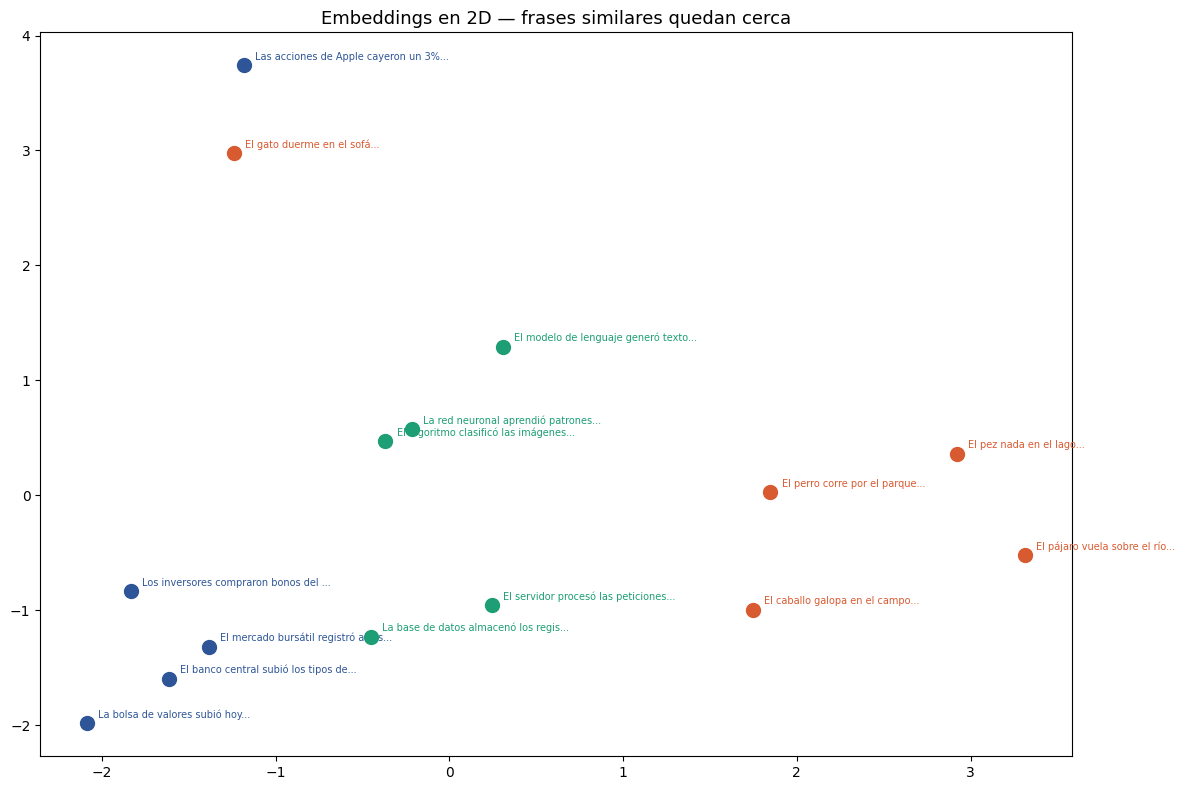

Varianza explicada por los 2 componentes: 29.8%


In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Más frases para que la visualización sea interesante
corpus = [
    # Cluster finanzas
    "La bolsa de valores subió hoy",
    "El mercado bursátil registró alzas",
    "Las acciones de Apple cayeron un 3%",
    "El banco central subió los tipos de interés",
    "Los inversores compraron bonos del estado",
    # Cluster animales
    "El perro corre por el parque",
    "El gato duerme en el sofá",
    "El caballo galopa en el campo",
    "El pájaro vuela sobre el río",
    "El pez nada en el lago",
    # Cluster tecnología
    "El modelo de lenguaje generó texto",
    "La red neuronal aprendió patrones",
    "El algoritmo clasificó las imágenes",
    "El servidor procesó las peticiones",
    "La base de datos almacenó los registros",
]

colores = ["#2E5597"] * 5 + ["#D85A30"] * 5 + ["#1D9E75"] * 5
labels = ["💰"] * 5 + ["🐾"] * 5 + ["💻"] * 5

vecs = np.vstack([get_embedding(f) for f in corpus])

# Reducir a 2 dimensiones para visualizar
pca = PCA(n_components=2)
coords = pca.fit_transform(vecs)

plt.figure(figsize=(12, 8))
for i, (x, y) in enumerate(coords):
    plt.scatter(x, y, color=colores[i], s=100, zorder=3)
    plt.annotate(
        corpus[i][:35] + "...",
        (x, y),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=7,
        color=colores[i]
    )

plt.title("Embeddings en 2D — frases similares quedan cerca", fontsize=13)
plt.tight_layout()
plt.savefig("embeddings_2d.png", dpi=150)
plt.show()
print(f"Varianza explicada por los 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

In [15]:
# Ahora busca por significado, como haría RAG
def buscar(pregunta, corpus, embeddings_corpus, top_k=3):
    q_vec = get_embedding(pregunta)[0]
    sims = [(cosine_similarity(q_vec, e), corpus[i]) 
            for i, e in enumerate(embeddings_corpus)]
    sims.sort(reverse=True)
    return sims[:top_k]

pregunta = "inversión en renta fija"
resultados = buscar(pregunta, corpus, vecs)

print(f"Pregunta: '{pregunta}'\n")
print("Resultados más relevantes:")
for sim, frase in resultados:
    print(f"  [{sim:.4f}] {frase}")

Pregunta: 'inversión en renta fija'

Resultados más relevantes:
  [0.4599] Los inversores compraron bonos del estado
  [0.3047] El mercado bursátil registró alzas
  [0.2410] El gato duerme en el sofá
